   prediction_id      route_id  vessel_id weather_period ballast_condition  \
0              6  rotterdam_ny          1        2025-01             laden   
1              5  rotterdam_ny          1        2025-01             laden   
2              4  rotterdam_ny          1        2025-07             laden   
3              3  rotterdam_ny          1        2025-01             laden   

   deadline_h  include_wind   dp_fuel_t  baseline_rpm  baseline_fuel_t  \
0  202.465052             0  405.226875          91.0       419.385991   
1  202.465052             0  405.226875          91.0       419.385991   
2  202.465052             0  333.884218          87.0       346.888774   
3  202.465052             0  405.226875          91.0       419.385991   

   savings_pct  is_feasible                        created_at  total_co2_t  \
0     3.376154            1  2026-09-05T17:32:40.324895+00:00  1261.876489   
1     3.376154            1  2026-09-05T17:30:37.540552+00:00  1261.876489   
2   

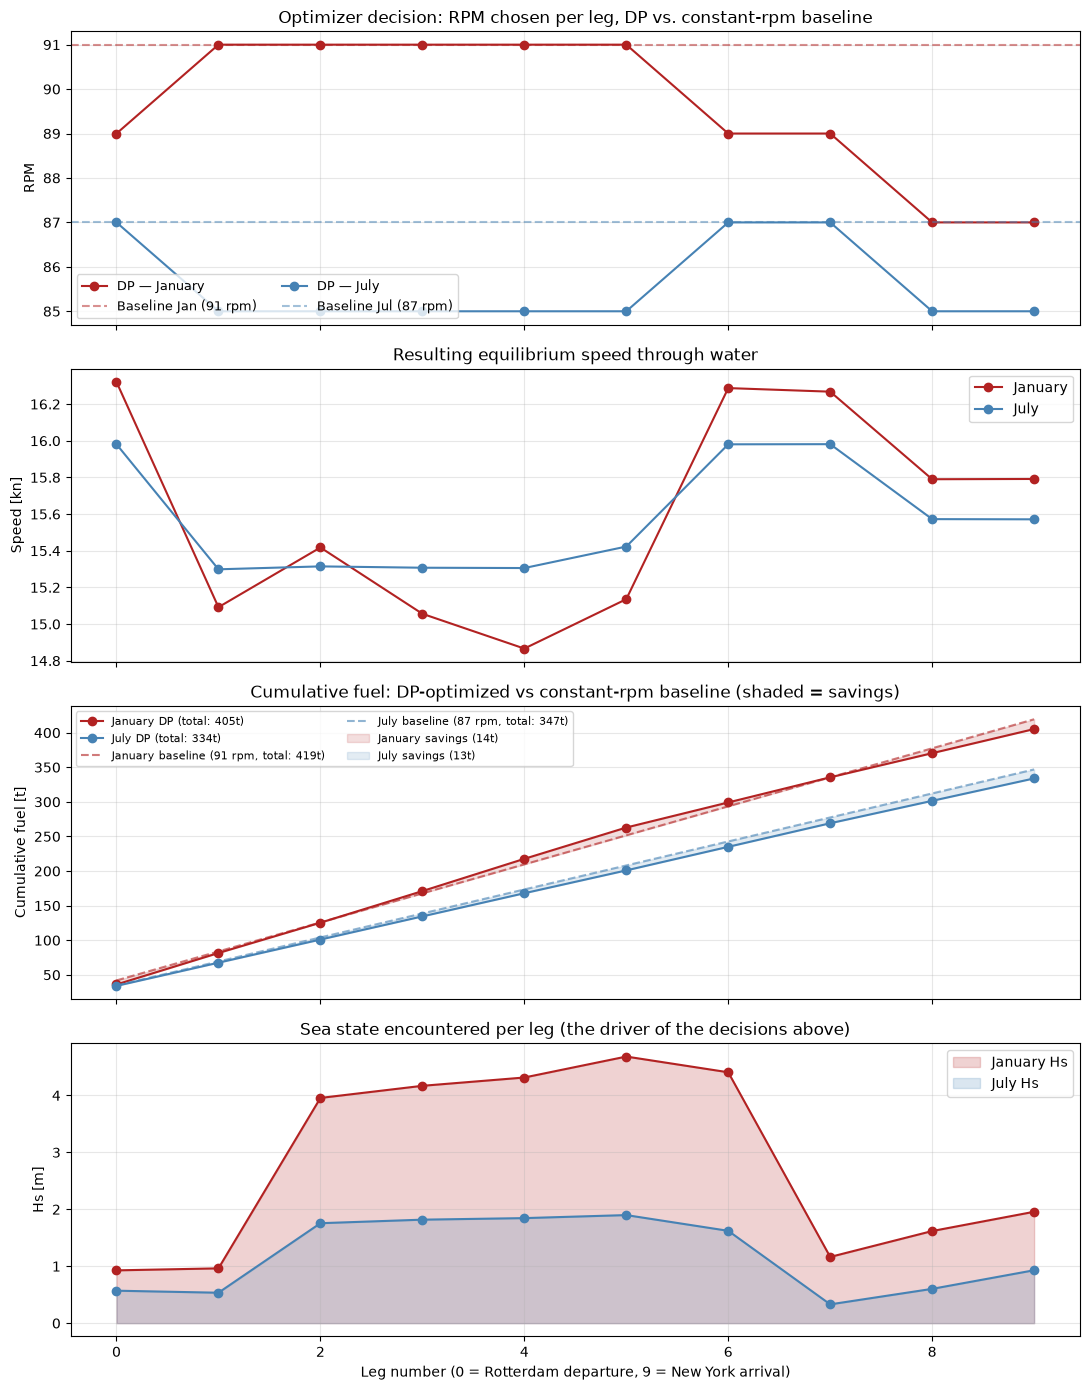

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from src.database.connection import get_connection
from src.database.queries import get_dashboard_summary, get_dashboard_legs, list_predictions

# ---- pick the two predictions to compare ----
conn = get_connection()
print(list_predictions(conn))          # eyeball this to find the right ids

JAN_ID = 3   # <-- change to your January (harsh) prediction_id
JUL_ID = 4   # <-- change to your July (calm) prediction_id

jan_summary = get_dashboard_summary(conn, JAN_ID)
jul_summary = get_dashboard_summary(conn, JUL_ID)
jan_legs = get_dashboard_legs(conn, JAN_ID)
jul_legs = get_dashboard_legs(conn, JUL_ID)
conn.close()

jan_baseline_rpm = jan_legs['baseline_rpm'].iloc[0]
jul_baseline_rpm = jul_legs['baseline_rpm'].iloc[0]

jan_dp_total = jan_legs['dp_fuel_t'].sum()
jan_base_total = jan_legs['baseline_fuel_t'].sum()
jul_dp_total = jul_legs['dp_fuel_t'].sum()
jul_base_total = jul_legs['baseline_fuel_t'].sum()

x = np.arange(len(jan_legs))  # leg numbers 0..9

fig, axes = plt.subplots(4, 1, figsize=(11, 14), sharex=True)

# ---- Panel 1: RPM chosen per leg, DP vs baseline ----
ax = axes[0]
ax.plot(x, jan_legs['dp_rpm'], marker='o', color='firebrick', label='DP — January')
ax.axhline(jan_baseline_rpm, color='firebrick', linestyle='--', alpha=0.5,
           label=f'Baseline Jan ({jan_baseline_rpm:.0f} rpm)')
ax.plot(x, jul_legs['dp_rpm'], marker='o', color='steelblue', label='DP — July')
ax.axhline(jul_baseline_rpm, color='steelblue', linestyle='--', alpha=0.5,
           label=f'Baseline Jul ({jul_baseline_rpm:.0f} rpm)')
ax.set_ylabel('RPM')
ax.set_title('Optimizer decision: RPM chosen per leg, DP vs. constant-rpm baseline')
ax.legend(loc='lower left', ncol=2, fontsize=9)
ax.grid(alpha=0.3)

# ---- Panel 2: Resulting equilibrium speed ----
ax = axes[1]
ax.plot(x, jan_legs['dp_v_kn'], marker='o', color='firebrick', label='January')
ax.plot(x, jul_legs['dp_v_kn'], marker='o', color='steelblue', label='July')
ax.set_ylabel('Speed [kn]')
ax.set_title('Resulting equilibrium speed through water')
ax.legend(loc='upper right')
ax.grid(alpha=0.3)

# ---- Panel 3: Cumulative fuel, DP vs baseline, shaded savings ----
ax = axes[2]
ax.plot(x, jan_legs['cum_dp_fuel_t'], marker='o', color='firebrick',
        label=f'January DP (total: {jan_dp_total:.0f}t)')
ax.plot(x, jul_legs['cum_dp_fuel_t'], marker='o', color='steelblue',
        label=f'July DP (total: {jul_dp_total:.0f}t)')

jan_cum_baseline = jan_legs['baseline_fuel_t'].cumsum()
jul_cum_baseline = jul_legs['baseline_fuel_t'].cumsum()
ax.plot(x, jan_cum_baseline, linestyle='--', color='firebrick', alpha=0.6,
        label=f'January baseline ({jan_baseline_rpm:.0f} rpm, total: {jan_base_total:.0f}t)')
ax.plot(x, jul_cum_baseline, linestyle='--', color='steelblue', alpha=0.6,
        label=f'July baseline ({jul_baseline_rpm:.0f} rpm, total: {jul_base_total:.0f}t)')

ax.fill_between(x, jan_legs['cum_dp_fuel_t'], jan_cum_baseline,
                color='firebrick', alpha=0.15,
                label=f'January savings ({jan_base_total - jan_dp_total:.0f}t)')
ax.fill_between(x, jul_legs['cum_dp_fuel_t'], jul_cum_baseline,
                color='steelblue', alpha=0.15,
                label=f'July savings ({jul_base_total - jul_dp_total:.0f}t)')

ax.set_ylabel('Cumulative fuel [t]')
ax.set_title('Cumulative fuel: DP-optimized vs constant-rpm baseline (shaded = savings)')
ax.legend(loc='upper left', ncol=2, fontsize=8)
ax.grid(alpha=0.3)

# ---- Panel 4: Sea state per leg ----
ax = axes[3]
ax.plot(x, jan_legs['hs_m'], marker='o', color='firebrick')
ax.fill_between(x, jan_legs['hs_m'], color='firebrick', alpha=0.2, label='January Hs')
ax.plot(x, jul_legs['hs_m'], marker='o', color='steelblue')
ax.fill_between(x, jul_legs['hs_m'], color='steelblue', alpha=0.2, label='July Hs')
ax.set_ylabel('Hs [m]')
ax.set_xlabel('Leg number (0 = Rotterdam departure, 9 = New York arrival)')
ax.set_title('Sea state encountered per leg (the driver of the decisions above)')
ax.legend(loc='upper right')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [2]:
from src.database.connection import run_emissions_migration
run_emissions_migration()

In [2]:
from src.orchestration import run_prediction
from src.database.connection import get_connection

pred_id_jul = run_prediction(weather_period='2025-07', include_wind=False)

conn = get_connection()
row = conn.execute(
    'SELECT total_co2_t, attained_cii, reference_cii, cii_rating FROM voyage_predictions WHERE prediction_id = ?',
    (pred_id_jul,)
).fetchone()
print(dict(row))
conn.close()

{'total_co2_t': 1039.7154542815176, 'attained_cii': 6.038621008200822, 'reference_cii': 7.608216288524462, 'cii_rating': 'A'}


In [3]:
from src.orchestration import run_prediction
from src.database.connection import get_connection
from src.database.queries import get_dashboard_summary, get_dashboard_legs

pred_id = run_prediction(weather_period='2025-01', include_wind=False)

conn = get_connection()
print(get_dashboard_summary(conn, pred_id))
print(get_dashboard_legs(conn, pred_id)[['leg_label', 'dp_fuel_t', 'co2_t']])
conn.close()

{'prediction_id': 10, 'route_id': 'rotterdam_ny', 'route_name': 'Rotterdam - New York', 'weather_period': '2025-01', 'weather_label': 'January (harsh)', 'ballast_condition': 'laden', 'dp_fuel_t': 405.22687511170017, 'baseline_fuel_t': 419.3859914727576, 'savings_pct': 3.3761538651624674, 'savings_label': '3.4% saved', 'is_feasible': 1, 'n_legs': 10, 'total_dist_nm': 3149.4563665493424, 'created_at': '2026-09-06T07:49:41.966995+00:00', 'total_co2_t': 1261.8764890978343, 'attained_cii': 7.3289223945282025, 'reference_cii': 7.608216288524462, 'cii_rating': 'C'}
  leg_label  dp_fuel_t       co2_t
0     Leg 1  36.101760  112.420880
1     Leg 2  45.463862  141.574467
2     Leg 3  43.836692  136.507459
3     Leg 4  45.647369  142.145908
4     Leg 5  46.633044  145.215298
5     Leg 6  45.241466  140.881926
6     Leg 7  36.245957  112.869910
7     Leg 8  36.330409  113.132893
8     Leg 9  34.866201  108.573350
9    Leg 10  34.860115  108.554398
